### **import**

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

### getting the dataset from kaggle

In [52]:
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
                            "shuofxz/titanic-machine-learning-from-disaster",
                            "train.csv")
df.info()
df.head()

C:\Users\tassili\AppData\Local\Temp\ipykernel_1252\1816360767.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### we can see that our data is not very clean, some rows are missing the age column and a significant number are missing the cabin column

### Now we are going to examine the other columns to see if they are valid

In [17]:
print(df["Survived"].value_counts(dropna=False))
print()

print(df["Sex"].value_counts(dropna=False))
print()

print(df["Pclass"].value_counts(dropna=False))
print()

print(df.isna().sum())
print()

Survived
0    549
1    342
Name: count, dtype: int64

Sex
male      577
female    314
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



### we can see that the columns of sex, survived and Pclass are all valid, where Age column have 177 not attributed rows

## **analysis of data**

## analysis of age relation with survival
### since, we have 177/891 missing rows for this column we're gonna check what the solution is in this case, depending on the different values our ages have 

25


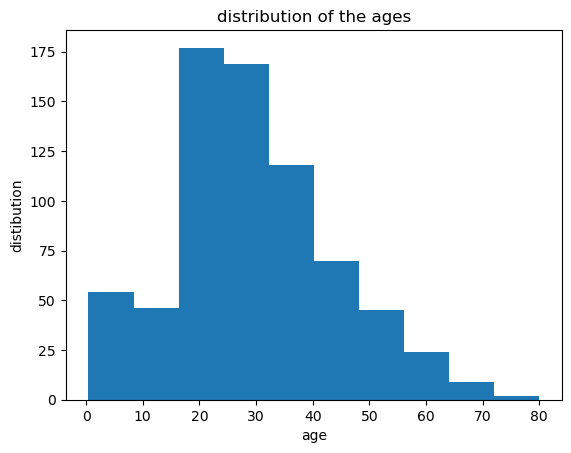

In [ ]:
print(df["Age"].value_counts(dropna=False))
plt.figure()
plt.hist(df["Age"])
plt.title("distribution of the ages")
plt.xlabel("age")
plt.ylabel("distibution")
plt.show()

### since we have a lot of different ages, here the best solution for machine learning purposes would be to fill with the median, but since we only want to study this data and analyse it, we will simply drop theses rows in order to get the most accurate answers we can

In [72]:
age_study = df.dropna(subset=["Age"]).copy()
print(age_study["Age"].value_counts(dropna=False))
bins = [0,10,20,30,40,50,60,70,80]

labels = [
    "0-10",
    "10-20",
    "20-30",
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70-80"
]
age_study["Age_group"] = pd.cut(age_study["Age"],
                                bins=bins,
                                labels=labels)

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64


### now we see the relation between the age and the survival chances

C:\Users\tassili\AppData\Local\Temp\ipykernel_1252\4258570426.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_per_age = age_study.groupby("Age_group")


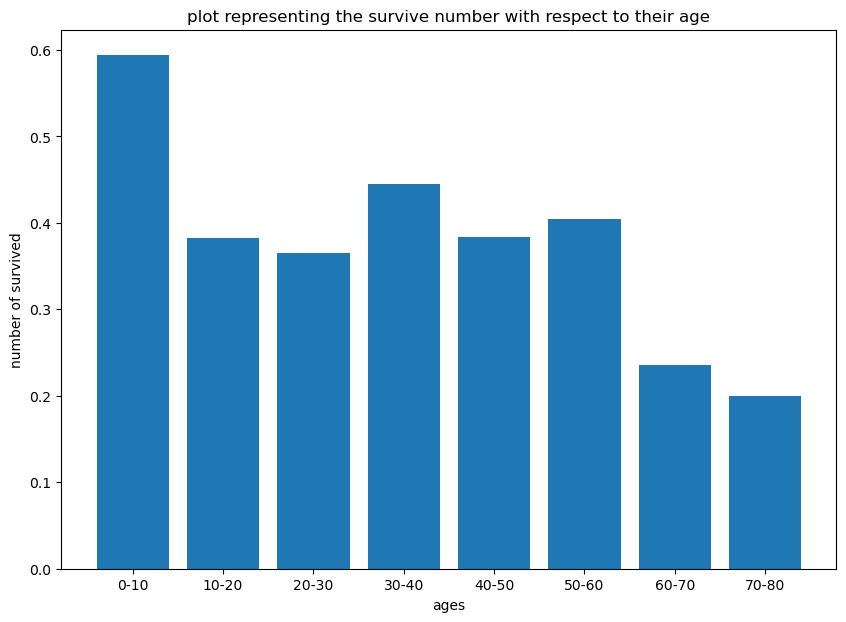

we can also calculation the correlation
-0.07722109457217764


In [75]:
group_per_age = age_study.groupby("Age_group")
survive_per_age = group_per_age["Survived"].mean()
plt.figure(figsize=(10,7))
plt.title("plot representing the survive number with respect to their age")
plt.bar(survive_per_age.index,survive_per_age.values)
plt.xlabel("ages")
plt.ylabel("number of survived")
plt.show()

print("we can also calculation the correlation")
correlation =age_study["Age"].corr(age_study["Survived"])
print(correlation)





### from this study, and from the fact that we founded the correlation to be 0.077, we can conclude that there is nearly no relation between the age and the chance of survival in the titanic, except that  we see a little lower chance of survival for people between age 20 and 30 also in the 60's

## Analysis of sex relation with survival chances

### here since our data is clean in the column of sex we can directly start the study

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


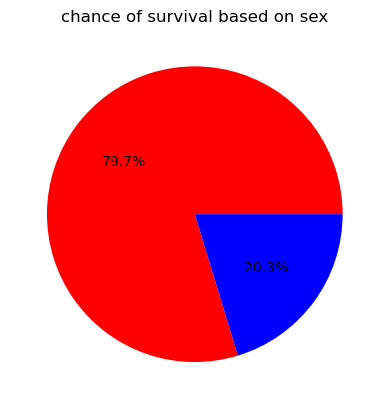

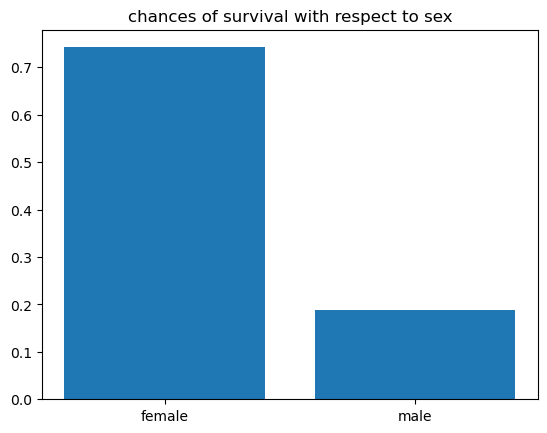

In [70]:
group_per_sex = df.groupby("Sex")
survive_per_sex_per = group_per_sex["Survived"].mean()
print(survive_per_sex_per)

plt.figure()
plt.title("chance of survival based on sex")
plt.pie(survive_per_sex_per,colors=["red","blue"],autopct="%1.1f%%")
plt.show()

plt.figure()
plt.title("chances of survival with respect to sex")
plt.bar(survive_per_sex_per.index,survive_per_sex_per.values)
plt.show()

#### no surprise here, most of females survived (74%) and most of men didnt (18%)

## analysis of the class relation with chance of survival

### here again our data is clean in this column, so we can begin directly

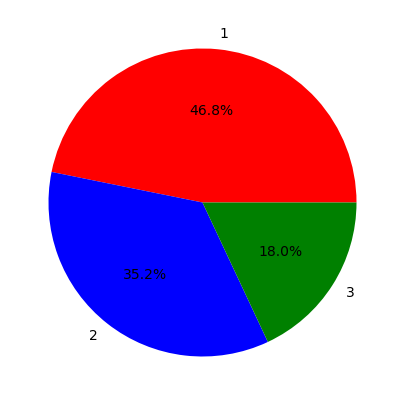

In [ ]:
group_per_class = df.groupby("Pclass")
group_per_class_per = group_per_class["Survived"].mean()
plt.figure(figsize=(10,5))
plt.title("pie representing the survival chances based on the Pclass")
plt.pie(group_per_class_per,labels=group_per_class_per.index,autopct="%1.1f%%",colors=["red","blue","green"])
plt.show()

### we can see a huge advantage and gain in the chance of survival for the people in the higher classes, proof that they were given a certain advantage in the rescue mission